1. Loading Dependencies

In [4]:
import os
import sys
import time
import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import DataLoader

In [5]:
# -------------------------------------------------
# Add project root to Python path
# -------------------------------------------------

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [6]:
# -------------------------------------------------
# Preprocessing
# -------------------------------------------------
from src.preprocessing.image_processing import (
    preprocess_image
)

from src.preprocessing.spectrogram import (
    preprocess_audio
)

# -------------------------------------------------
# Dataset processing
# -------------------------------------------------

from src.datasets.label_processing import (
    prepare_binary_labels
)

from src.datasets.multimodal_dataset import (
    MultimodalDataset
)

# -------------------------------------------------
# Models
# -------------------------------------------------
from src.models.semantic_alignment import (
    SharedConvNet,
    ClassifierNet
)
# from src.models.fusion import FeatureFusionModel
# from src.models.baselines import VisualOnlyCNN
# from src.models.baselines import AudioOnlyCNN

# -------------------------------------------------
# Training
# -------------------------------------------------
from src.training.trainer import (
    Trainer
)

# -------------------------------------------------
# Evaluation
# -------------------------------------------------
from src.evaluation.metrics import evaluate_model

# -------------------------------------------------
# Explainability
# -------------------------------------------------
from src.explainability.lime_analysis import run_lime

2. Loading Raw Data

In [7]:
# -------------------------------------------------
# Dataset paths
# -------------------------------------------------
VISUAL_FOLDER = "../data/raw/images"

AUDIO_FOLDER = "../data/raw/audio_files"

LABEL_PATH = "../data/raw/labels/annotations_1.csv"

# -------------------------------------------------
# Output paths
# -------------------------------------------------

OUTPUT_FOLDER = "../outputs"

os.makedirs(
    OUTPUT_FOLDER,
    exist_ok=True
)

In [8]:
# -------------------------------------------------
# Load Raw Data
# -------------------------------------------------

visual_files = sorted(os.listdir(VISUAL_FOLDER))
audio_files = sorted(os.listdir(AUDIO_FOLDER))

print("Number of visual files:", len(visual_files))
print("Number of audio files:", len(audio_files))

Number of visual files: 4624
Number of audio files: 4624


In [9]:
# -------------------------------------------------
# Load metadata
# -------------------------------------------------

metadata = pd.read_csv(
    LABEL_PATH
)

print(metadata.head())

print(metadata.shape)

   sample index audio_file_name image_file_name  Layer number   class_name
0             1  sample_1_1.wav  sample_1_1.jpg           1.0  Defect-free
1             2  sample_1_2.wav  sample_1_2.jpg           1.0  Defect-free
2             3  sample_1_3.wav  sample_1_3.jpg           1.0  Defect-free
3             4  sample_1_4.wav  sample_1_4.jpg           1.0  Defect-free
4             5  sample_1_5.wav  sample_1_5.jpg           1.0  Defect-free
(4624, 5)


In [10]:
# -------------------------------------------------
# Prepare binary labels
# -------------------------------------------------

metadata, labels = prepare_binary_labels(
    metadata
)

# -------------------------------------------------
# Verify labels
# -------------------------------------------------

print("Metadata shape:")

print(metadata.shape)

print("Unique labels:")

print(np.unique(labels))

print("NaN labels:")

print(np.isnan(labels).sum())

Metadata shape:
(4345, 5)
Unique labels:
[0 1]
NaN labels:
0


In [11]:
# -------------------------------------------------
# Get valid filenames
# -------------------------------------------------

image_filenames = metadata[
    "image_file_name"
].values

audio_filenames = metadata[
    "audio_file_name"
].values

print("Number of image files:")

print(len(image_filenames))

print("Number of audio files:")

print(len(audio_filenames))

Number of image files:
4345
Number of audio files:
4345


3. Data Preprocessing

In [12]:
# -------------------------------------------------
# Preprocess Image Data
# -------------------------------------------------

# -------------------------------------------------
# Create image dataset container
# -------------------------------------------------

im_dataset = np.zeros(
    (
        len(image_filenames),
        80,
        80
    )
)

image_sample_record = []

# -------------------------------------------------
# Start timer
# -------------------------------------------------

t0 = time.time()

# -------------------------------------------------
# Preprocess images
# -------------------------------------------------

for i in range(len(image_filenames)):

    print(
        f"Processing image {i+1}/{len(image_filenames)}"
    )

    image_path = os.path.join(
        VISUAL_FOLDER,
        image_filenames[i]
    )

    processed_image = preprocess_image(
        image_path
    )

    image_sample_record.append([
        image_filenames[i],
        processed_image
    ])

    im_dataset[i] = processed_image

print(
    "Image preprocessing time:",
    time.time() - t0
)

print(im_dataset.shape)

Processing image 1/4345
Processing image 2/4345
Processing image 3/4345
Processing image 4/4345
Processing image 5/4345
Processing image 6/4345
Processing image 7/4345
Processing image 8/4345
Processing image 9/4345
Processing image 10/4345
Processing image 11/4345
Processing image 12/4345
Processing image 13/4345
Processing image 14/4345
Processing image 15/4345
Processing image 16/4345
Processing image 17/4345
Processing image 18/4345
Processing image 19/4345
Processing image 20/4345
Processing image 21/4345
Processing image 22/4345
Processing image 23/4345
Processing image 24/4345
Processing image 25/4345
Processing image 26/4345
Processing image 27/4345
Processing image 28/4345
Processing image 29/4345
Processing image 30/4345
Processing image 31/4345
Processing image 32/4345
Processing image 33/4345
Processing image 34/4345
Processing image 35/4345
Processing image 36/4345
Processing image 37/4345
Processing image 38/4345
Processing image 39/4345
Processing image 40/4345
Processin

In [13]:
# -------------------------------------------------
# Preprocess Audio Data
# -------------------------------------------------

# -------------------------------------------------
# Create spectrogram container
# -------------------------------------------------

spectrograms = np.zeros(
    (
        len(audio_filenames),
        80,
        80
    )
)

audio_sample_record = []

# -------------------------------------------------
# Generate spectrograms
# -------------------------------------------------

for i in range(len(audio_filenames)):

    print(
        f"Processing audio {i+1}/{len(audio_filenames)}"
    )

    wav_path = os.path.join(
        AUDIO_FOLDER,
        audio_filenames[i]
    )

    processed_spec = preprocess_audio(
        wav_path
    )

    audio_sample_record.append([
        audio_filenames[i],
        processed_spec
    ])

    spectrograms[i] = processed_spec

print(spectrograms.shape)

Processing audio 1/4345
Processing audio 2/4345
Processing audio 3/4345
Processing audio 4/4345
Processing audio 5/4345
Processing audio 6/4345
Processing audio 7/4345
Processing audio 8/4345
Processing audio 9/4345
Processing audio 10/4345
Processing audio 11/4345
Processing audio 12/4345
Processing audio 13/4345
Processing audio 14/4345
Processing audio 15/4345
Processing audio 16/4345


c:\Users\jiaru\.conda\envs\AM_MM_use\lib\site-packages\matplotlib\axes\_axes.py:7774: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


Processing audio 17/4345
Processing audio 18/4345
Processing audio 19/4345
Processing audio 20/4345
Processing audio 21/4345
Processing audio 22/4345
Processing audio 23/4345
Processing audio 24/4345
Processing audio 25/4345
Processing audio 26/4345
Processing audio 27/4345
Processing audio 28/4345
Processing audio 29/4345
Processing audio 30/4345
Processing audio 31/4345
Processing audio 32/4345
Processing audio 33/4345
Processing audio 34/4345
Processing audio 35/4345
Processing audio 36/4345
Processing audio 37/4345
Processing audio 38/4345
Processing audio 39/4345
Processing audio 40/4345
Processing audio 41/4345
Processing audio 42/4345
Processing audio 43/4345
Processing audio 44/4345
Processing audio 45/4345
Processing audio 46/4345
Processing audio 47/4345
Processing audio 48/4345
Processing audio 49/4345
Processing audio 50/4345
Processing audio 51/4345
Processing audio 52/4345
Processing audio 53/4345
Processing audio 54/4345
Processing audio 55/4345
Processing audio 56/4345


In [14]:
# -------------------------------------------------
# Standardize modality variable names
# -------------------------------------------------

visual_data = im_dataset

audio_data = spectrograms

print("Visual data shape:")

print(visual_data.shape)

print("Audio data shape:")

print(audio_data.shape)

Visual data shape:
(4345, 80, 80)
Audio data shape:
(4345, 80, 80)


In [15]:
# -------------------------------------------------
# Train/Validation/Test Split
# -------------------------------------------------

Xv_train, Xv_temp, Xa_train, Xa_temp, y_train, y_temp = train_test_split(
    visual_data,
    audio_data,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

Xv_val, Xv_test, Xa_val, Xa_test, y_val, y_test = train_test_split(
    Xv_temp,
    Xa_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# -------------------------------------------------
# Print dataset shapes
# -------------------------------------------------

print("Training visual data:")

print(Xv_train.shape)

print("Training audio data:")

print(Xa_train.shape)

print("Validation visual data:")

print(Xv_val.shape)

print("Validation audio data:")

print(Xa_val.shape)

print("Testing visual data:")

print(Xv_test.shape)

print("Testing audio data:")

print(Xa_test.shape)

Training visual data:
(3476, 80, 80)
Training audio data:
(3476, 80, 80)
Validation visual data:
(434, 80, 80)
Validation audio data:
(434, 80, 80)
Testing visual data:
(435, 80, 80)
Testing audio data:
(435, 80, 80)


In [16]:
# -------------------------------------------------
# Create PyTorch datasets
# -------------------------------------------------

train_dataset = MultimodalDataset(
    Xv_train,
    Xa_train,
    y_train
)

val_dataset = MultimodalDataset(
    Xv_val,
    Xa_val,
    y_val
)

test_dataset = MultimodalDataset(
    Xv_test,
    Xa_test,
    y_test
)

In [17]:
# -------------------------------------------------
# Create DataLoaders
# -------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [18]:
# -------------------------------------------------
# Inspect one sample
# -------------------------------------------------

sample = train_dataset[0]

print(sample.keys())

print("Visual tensor shape:")

print(sample["visual"].shape)

print("Audio tensor shape:")

print(sample["audio"].shape)

print("Label:")

print(sample["label"])

dict_keys(['visual', 'audio', 'label'])
Visual tensor shape:
torch.Size([1, 80, 80])
Audio tensor shape:
torch.Size([1, 80, 80])
Label:
tensor(1.)


4. Model Training

In [19]:
# -------------------------------------------------
# Define computation device
# -------------------------------------------------

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:")

print(DEVICE)

Using device:
cuda


In [20]:
# -------------------------------------------------
# Training hyperparameters
# -------------------------------------------------

EPOCHS = 1200

LEARNING_RATE = 0.000484674265378098

WEIGHT_DECAY = 0.000793891463437805

MARGIN = 1.0

GAMMA = 0.5

print("Epochs:", EPOCHS)

print("Learning rate:", LEARNING_RATE)

print("Weight decay:", WEIGHT_DECAY)

print("Margin:", MARGIN)

print("Gamma:", GAMMA)

Epochs: 1200
Learning rate: 0.000484674265378098
Weight decay: 0.000793891463437805
Margin: 1.0
Gamma: 0.5


In [21]:
# -------------------------------------------------
# Initialize shared feature extractor
# -------------------------------------------------

encoder_net = SharedConvNet(
    num_conv_layers=2,
    filters1=30,
    filters2=32,
    kernel_size=3
)

encoder_net = encoder_net.to(
    DEVICE
)

print(encoder_net)

SharedConvNet(
  (conv_layers): ModuleList(
    (0): Conv2d(1, 30, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1-2): 2 x Conv2d(30, 30, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (3): Conv2d(30, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
  )
  (pool_layers): ModuleList(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1-2): 2 x MaxPool2d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
    (3-4): 2 x MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
)


In [22]:
# -------------------------------------------------
# Initialize shared classifier
# -------------------------------------------------

task_net = ClassifierNet(
    dense_units1=220,
    output_dims=[93],
    drops=0.0752054726602688,
    filters2=32
)

task_net = task_net.to(
    DEVICE
)

print(task_net)

ClassifierNet(
  (dense_layers): ModuleList(
    (0): Linear(in_features=6400, out_features=220, bias=True)
    (1): Linear(in_features=220, out_features=93, bias=True)
  )
  (drop_layers): ModuleList(
    (0-1): 2 x Dropout(p=0.0752054726602688, inplace=False)
  )
  (fc3): Linear(in_features=93, out_features=1, bias=True)
)


In [23]:
# -------------------------------------------------
# Initialize optimizers
# -------------------------------------------------

encoder_optimizer = torch.optim.Adam(
    encoder_net.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

classifier_optimizer = torch.optim.Adam(
    task_net.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [24]:
# -------------------------------------------------
# Initialize semantic alignment trainer
# -------------------------------------------------

trainer = Trainer(
    encoder_net=encoder_net,
    task_net=task_net,
    encoder_optimizer=encoder_optimizer,
    classifier_optimizer=classifier_optimizer,
    device=DEVICE,
    margin=MARGIN,
    gamma=GAMMA
)

In [25]:
# -------------------------------------------------
# Temporary source/target setup
# -------------------------------------------------

source_loader = train_loader

In [ ]:
# -------------------------------------------------
# Train semantic alignment framework
# -------------------------------------------------

history = trainer.fit(
    train_loader=train_loader,
    epochs=EPOCHS
)

Epoch 1/1200
Encoder Loss: 864.3051
Alignment Loss: 1727.5804
Task Loss: 1.0298
Accuracy: 0.7388
Epoch 2/1200
Encoder Loss: 0.8437
Alignment Loss: 0.7439
Task Loss: 0.9435
Accuracy: 0.8642
Epoch 3/1200
Encoder Loss: 0.5591
Alignment Loss: 0.5812
Task Loss: 0.5370
Accuracy: 0.9295
Epoch 4/1200
Encoder Loss: 0.4575
Alignment Loss: 0.5194
Task Loss: 0.3955
Accuracy: 0.9422
Epoch 5/1200
Encoder Loss: 0.4033
Alignment Loss: 0.4867
Task Loss: 0.3199
Accuracy: 0.9459
Epoch 6/1200
Encoder Loss: 0.3765
Alignment Loss: 0.4657
Task Loss: 0.2874
Accuracy: 0.9474
Epoch 7/1200
Encoder Loss: 0.3586
Alignment Loss: 0.4569
Task Loss: 0.2603
Accuracy: 0.9580
Epoch 8/1200
Encoder Loss: 0.3502
Alignment Loss: 0.4486
Task Loss: 0.2518
Accuracy: 0.9551
Epoch 9/1200
Encoder Loss: 0.3364
Alignment Loss: 0.4409
Task Loss: 0.2318
Accuracy: 0.9543
Epoch 10/1200
Encoder Loss: 0.3239
Alignment Loss: 0.4282
Task Loss: 0.2196
Accuracy: 0.9606
Epoch 11/1200
Encoder Loss: 0.3162
Alignment Loss: 0.4163
Task Loss: 0.216

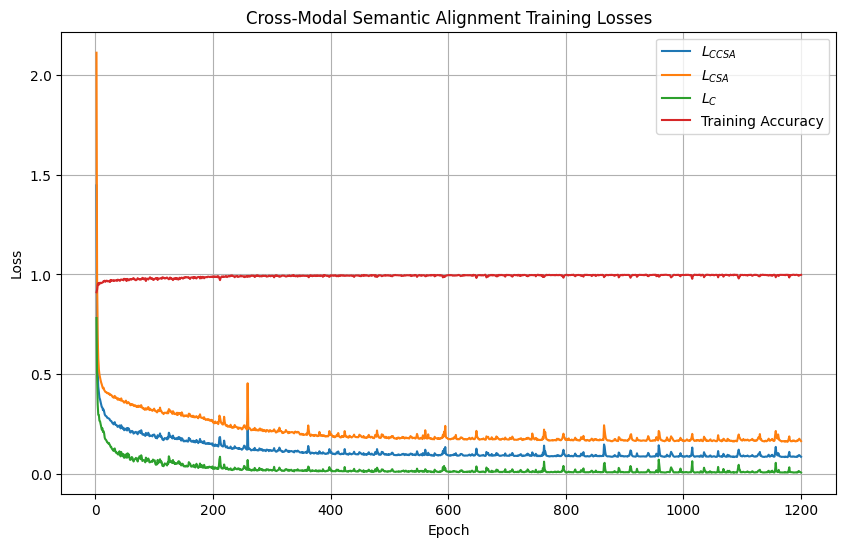

In [ ]:
# -------------------------------------------------
# Plot training losses (skip first epoch)
# -------------------------------------------------

epochs = range(
    2,
    EPOCHS + 1
)

plt.figure(figsize=(10, 6))

# ----------------------------------------------
# L_CCSA
# ----------------------------------------------

plt.plot(
    epochs,
    history["encoder_loss"][1:],
    label=r"$L_{CCSA}$"
)

# ----------------------------------------------
# L_CSA
# ----------------------------------------------

plt.plot(
    epochs,
    history["alignment_loss"][1:],
    label=r"$L_{CSA}$"
)

# ----------------------------------------------
# L_C
# ----------------------------------------------

plt.plot(
    epochs,
    history["task_loss"][1:],
    label=r"$L_{C}$"
)

plt.plot(
    epochs,
    history["accuracy"][1:],
    label="Training Accuracy"
)

# ----------------------------------------------
# Figure settings
# ----------------------------------------------

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Cross-Modal Semantic Alignment Training Losses"
)

plt.legend()

plt.grid(True)

plt.show()

5. Model Evaluation

In [29]:
# -------------------------------------------------
# Evaluate visual-only deployment performance
# -------------------------------------------------

results = evaluate_model(
    encoder_net=encoder_net,
    task_net=task_net,
    dataloader=test_loader,
    device=DEVICE
)


Evaluation Results
----------------------------------------
Accuracy : 0.9793
Precision: 0.9938
Recall   : 0.9785
F1 Score : 0.9861

Confusion Matrix
[[107   2]
 [  7 319]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.94      0.98      0.96       109
         1.0       0.99      0.98      0.99       326

    accuracy                           0.98       435
   macro avg       0.97      0.98      0.97       435
weighted avg       0.98      0.98      0.98       435



6. LIME Explainability

In [ ]:
# -------------------------------------------------
# Select sample from test dataset
# -------------------------------------------------

sample = test_dataset[0]

visual_sample = sample["visual"]

label = sample["label"]

print("Ground truth label:")

print(label)

In [ ]:
# -------------------------------------------------
# Visualize melt pool image
# -------------------------------------------------

plt.figure(figsize=(5,5))

plt.imshow(
    visual_sample.squeeze(),
    cmap="gray"
)

plt.title(
    "Original Melt Pool Image"
)

plt.axis("off")

plt.show()

In [ ]:
# -------------------------------------------------
# Run LIME explanation
# -------------------------------------------------

explanation = run_lime(
    encoder_net=encoder_net,
    task_net=task_net,
    image=visual_sample,
    device=DEVICE,
    num_samples=1000
)